In [ ]:
import polars as pl
import numpy as np
import seaborn as sns
import pandas as pd
import polars.selectors as cs
import matplotlib.pyplot as plt

In [ ]:
df = pl.read_csv("/content/titanic.csv")

In [ ]:
# Display the first 10 records.
print(df.head(10))

shape: (10, 15)
┌──────────┬────────┬────────┬──────┬───┬──────┬─────────────┬───────┬───────┐
│ survived ┆ pclass ┆ sex    ┆ age  ┆ … ┆ deck ┆ embark_town ┆ alive ┆ alone │
│ ---      ┆ ---    ┆ ---    ┆ ---  ┆   ┆ ---  ┆ ---         ┆ ---   ┆ ---   │
│ i64      ┆ i64    ┆ str    ┆ f64  ┆   ┆ str  ┆ str         ┆ str   ┆ bool  │
╞══════════╪════════╪════════╪══════╪═══╪══════╪═════════════╪═══════╪═══════╡
│ 0        ┆ 3      ┆ male   ┆ 22.0 ┆ … ┆ null ┆ Southampton ┆ no    ┆ false │
│ 1        ┆ 1      ┆ female ┆ 38.0 ┆ … ┆ C    ┆ Cherbourg   ┆ yes   ┆ false │
│ 1        ┆ 3      ┆ female ┆ 26.0 ┆ … ┆ null ┆ Southampton ┆ yes   ┆ true  │
│ 1        ┆ 1      ┆ female ┆ 35.0 ┆ … ┆ C    ┆ Southampton ┆ yes   ┆ false │
│ 0        ┆ 3      ┆ male   ┆ 35.0 ┆ … ┆ null ┆ Southampton ┆ no    ┆ true  │
│ 0        ┆ 3      ┆ male   ┆ null ┆ … ┆ null ┆ Queenstown  ┆ no    ┆ true  │
│ 0        ┆ 1      ┆ male   ┆ 54.0 ┆ … ┆ E    ┆ Southampton ┆ no    ┆ true  │
│ 0        ┆ 3      ┆ male   ┆ 2.0  

In [ ]:
# Find the number of rows and columns.
rows, cols = df.shape
print(f"rows: {rows}, cols: {cols}")

rows: 891, cols: 15


In [ ]:
# Display the data types of all variables.
for col_name, dtype in df.schema.items():
    print(f"{col_name:15}: {dtype}")

survived       : Int64
pclass         : Int64
sex            : String
age            : Float64
sibsp          : Int64
parch          : Int64
fare           : Float64
embarked       : String
class          : String
who            : String
adult_male     : Boolean
deck           : String
embark_town    : String
alive          : String
alone          : Boolean


In [ ]:
# Identify missing values in each column.
null_counts = df.null_count()
print(null_counts)

shape: (1, 15)
┌──────────┬────────┬─────┬─────┬───┬──────┬─────────────┬───────┬───────┐
│ survived ┆ pclass ┆ sex ┆ age ┆ … ┆ deck ┆ embark_town ┆ alive ┆ alone │
│ ---      ┆ ---    ┆ --- ┆ --- ┆   ┆ ---  ┆ ---         ┆ ---   ┆ ---   │
│ u32      ┆ u32    ┆ u32 ┆ u32 ┆   ┆ u32  ┆ u32         ┆ u32   ┆ u32   │
╞══════════╪════════╪═════╪═════╪═══╪══════╪═════════════╪═══════╪═══════╡
│ 0        ┆ 0      ┆ 0   ┆ 177 ┆ … ┆ 688  ┆ 2           ┆ 0     ┆ 0     │
└──────────┴────────┴─────┴─────┴───┴──────┴─────────────┴───────┴───────┘


In [ ]:
# Find the mean age of passengers.
mean_age_pl = df.select(pl.col("age").mean()).item()
print(f"Mean Age: {mean_age_pl:.2f}")

Mean Age: 29.70


In [ ]:
# Find the number of male and female passengers.
gender_counts = df.group_by("sex").len()
print(gender_counts)

shape: (2, 2)
┌────────┬─────┐
│ sex    ┆ len │
│ ---    ┆ --- │
│ str    ┆ u32 │
╞════════╪═════╡
│ male   ┆ 577 │
│ female ┆ 314 │
└────────┴─────┘


In [ ]:
# Calculate the survival rate.
survival_rate = df.select(pl.col("survived").mean()).item()
print(f"Survival Rate: {survival_rate * 100:.2f}")

Survival Rate: 38.38


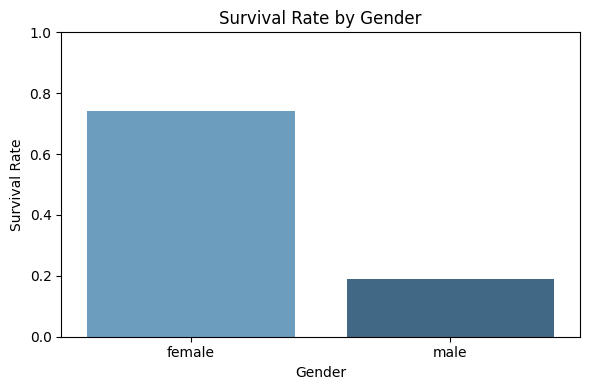

In [ ]:
# Create a bar chart showing survival by gender.
survival_by_gender = (
    df.group_by("sex")
    .agg(pl.col("survived").mean().alias("survival_rate"))
    .sort("sex")
)

plt.figure(figsize=(6, 4))
sns.barplot(
    x=survival_by_gender["sex"].to_numpy(),
    y=survival_by_gender["survival_rate"].to_numpy(),
    palette="Blues_d",
    hue=survival_by_gender["sex"].to_numpy(),
)
plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

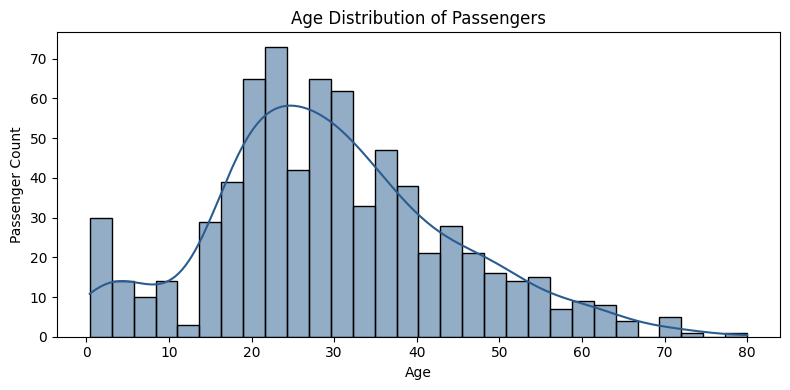

In [ ]:
# Create a histogram of passenger ages.
age = df.select(pl.col("age").drop_nulls())["age"].to_numpy()

plt.figure(figsize=(8, 4))
sns.histplot(age, bins=30, kde=True, color="#2b5c8f")
plt.title("Age Distribution of Passengers")
plt.xlabel("Age")
plt.ylabel("Passenger Count")
plt.tight_layout()
plt.show()

shape: (6, 6)
┌───────────┬───────────┬─────┬───────────┬──────────┬──────────┐
│ survived  ┆ pclass    ┆ age ┆ sibsp     ┆ parch    ┆ fare     │
│ ---       ┆ ---       ┆ --- ┆ ---       ┆ ---      ┆ ---      │
│ f64       ┆ f64       ┆ f64 ┆ f64       ┆ f64      ┆ f64      │
╞═══════════╪═══════════╪═════╪═══════════╪══════════╪══════════╡
│ 1.0       ┆ -0.338481 ┆ NaN ┆ -0.035322 ┆ 0.081629 ┆ 0.257307 │
│ -0.338481 ┆ 1.0       ┆ NaN ┆ 0.083081  ┆ 0.018443 ┆ -0.5495  │
│ NaN       ┆ NaN       ┆ NaN ┆ NaN       ┆ NaN      ┆ NaN      │
│ -0.035322 ┆ 0.083081  ┆ NaN ┆ 1.0       ┆ 0.414838 ┆ 0.159651 │
│ 0.081629  ┆ 0.018443  ┆ NaN ┆ 0.414838  ┆ 1.0      ┆ 0.216225 │
│ 0.257307  ┆ -0.5495   ┆ NaN ┆ 0.159651  ┆ 0.216225 ┆ 1.0      │
└───────────┴───────────┴─────┴───────────┴──────────┴──────────┘


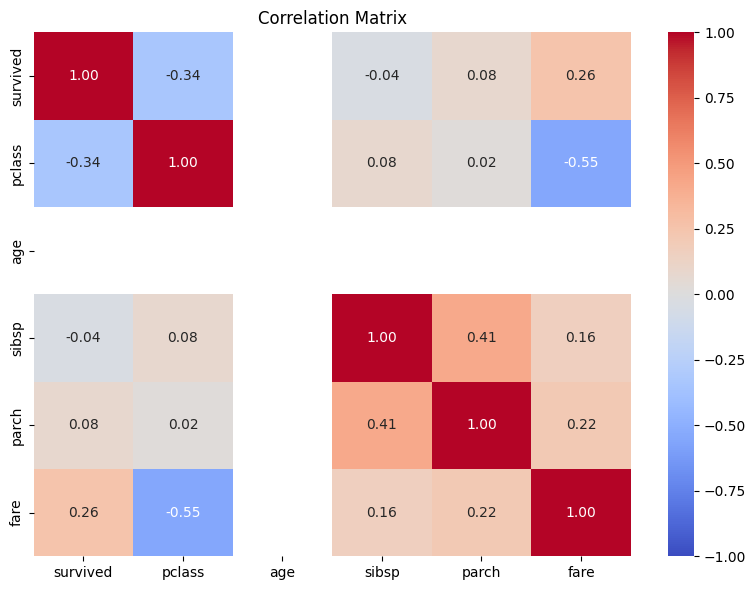

In [ ]:
# Find the correlation between numerical variables.
numeric_df = df.select(cs.numeric())
corr_matrix = numeric_df.corr()

print(corr_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix.to_numpy(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    xticklabels=numeric_df.columns,
    yticklabels=numeric_df.columns,
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()